# Disease and PPI network properties

This notebook has two deliberately separate parts:

1. **Disease observables** are computed for every disease, visualized across diseases, and persisted to `data/processed/diseases_prop.pkl`.
2. **Whole-PPI graph diagnostics** describe the interactome itself (and disease annotations on it). They are exploratory and are **not** written to the disease pickle.

All disease-pathway calculations use the disease proteins present in the loaded PPI graph. The original disease gene list and the missing proteins are retained so that PPI coverage remains explicit.

## Setup and data loading

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "bioGraph").is_dir():
    raise FileNotFoundError(
        "Start Jupyter from the repository root or the notebooks directory."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pickle

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse.csgraph import shortest_path

from bioGraph.data.loading import load_disease_genes, load_ppi_graph

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:  # Matplotlib < 3.6
    plt.style.use("seaborn-whitegrid")
RANDOM_SEED = 0

In [3]:
data_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

ppi_path = data_dir / "PPI202207.txt"
disease_path = data_dir / "pcbi.1004120.s004.txt"
disease_properties_path = processed_dir / "diseases_prop.pkl"

Ggen = load_ppi_graph(ppi_path)
diseases = load_disease_genes(disease_path)
nodelist = list(Ggen.nodes())
node_to_index = {node: index for index, node in enumerate(nodelist)}

print(
    f"Loaded PPI graph: {Ggen.number_of_nodes():,} nodes, "
    f"{Ggen.number_of_edges():,} undirected edges."
)
print(f"Loaded {len(diseases)} diseases.")
print(
    "Mean annotated genes per disease: "
    f"{np.mean([len(genes) for genes in diseases.values()]):.2f}"
)

Loaded PPI graph: 17,504 nodes, 354,647 undirected edges.
Loaded 70 diseases.
Mean annotated genes per disease: 40.61


# Part I — Disease observables (persisted)

For a disease (d), let (V_d) be its proteins found in the PPI graph, (E_d) the PPI edges induced by those proteins, and (B_d) the edges with exactly one endpoint in (V_d). The following quantities are stored:

- **PPI coverage:** fraction of unique annotated disease proteins found in the PPI graph.
- **Components and LCC fraction:** connected components of the induced pathway $H_d=(V_d,E_d)$, and $\lvert\mathrm{LCC}_d\rvert/\lvert V_d\rvert$.
- **Pathway density:** $2\lvert E_d\rvert/[\lvert V_d\rvert(\lvert V_d\rvert-1)]$. It is defined as 0 for fewer than two PPI proteins.
- **Component distance:** for every unordered pair of induced components, first average all finite PPI shortest-path distances between the two protein sets, then average those component-pair means. Unreachable component pairs are recorded as `NaN` and excluded from the scalar mean; their fraction is stored separately. A one-component pathway has distance 0.
- **Conductance:** $\lvert B_d\rvert/(\lvert B_d\rvert+2\lvert E_d\rvert)$.
- **Spatial network association:** the requested $K_d(s)$ with the strict condition $G(i,j)<s$, evaluated at integer scales 1–7. Its trapezoidal AUC is compared with size-matched protein sets sampled uniformly without replacement from all PPI nodes.
- **Network modularity:** modularity of the binary partition $\{V_d,V\setminus V_d\}$, matching the supplied $\delta(p_i,p_j)$ definition.

For backward compatibility, `genes`, `numb_genes`, `clusters`, `cluster_sizes`, and `cluster_distances` remain in every disease record. The legacy `cluster_distances` field contains the minimum PPI distance between component pairs; the new `component_mean_distance_matrix` contains the requested pairwise means.

### Computation controls

In [4]:
# Set this to True to force a refresh. An old/incomplete pickle is refreshed automatically.
RECOMPUTE_DISEASE_PROPERTIES = False

# Random sets used for the spatial-association null distribution.
N_SPATIAL_RANDOM = 250
SPATIAL_SCALES = np.arange(1, 8, dtype=np.uint8)

# A larger batch is faster but temporarily uses more memory. The final compressed
# all-pairs matrix occupies about n_nodes**2 bytes (roughly 307 MB for this PPI).
DISTANCE_BATCH_SIZE = 128
UNREACHABLE = np.iinfo(np.uint8).max

REQUIRED_DISEASE_KEYS = {
    "genes_in_ppi",
    "ppi_coverage",
    "largest_component_fraction",
    "pathway_density",
    "mean_component_distance",
    "conductance",
    "spatial_association_auc",
    "spatial_association_pvalue",
    "network_modularity",
}

### Helper functions

In [5]:
def _ppi_adjacency(graph, ordered_nodes):
    '''Return a SciPy CSR adjacency matrix across NetworkX versions.'''
    if hasattr(nx, "to_scipy_sparse_array"):
        return nx.to_scipy_sparse_array(
            graph, nodelist=ordered_nodes, dtype=np.uint8, format="csr"
        )
    return nx.to_scipy_sparse_matrix(
        graph, nodelist=ordered_nodes, dtype=np.uint8, format="csr"
    )


def compressed_all_pairs_distances(graph, ordered_nodes, batch_size=128):
    '''Compute exact unweighted distances, using uint8(255) for unreachable pairs.'''
    adjacency = _ppi_adjacency(graph, ordered_nodes)
    n_nodes = len(ordered_nodes)
    profiles = np.empty((n_nodes, n_nodes), dtype=np.uint8)
    n_batches = int(np.ceil(n_nodes / batch_size))

    for batch_number, start in enumerate(range(0, n_nodes, batch_size), start=1):
        stop = min(start + batch_size, n_nodes)
        distances = shortest_path(
            adjacency,
            directed=False,
            unweighted=True,
            indices=np.arange(start, stop),
        )
        finite = np.isfinite(distances)
        if finite.any() and distances[finite].max() >= UNREACHABLE:
            raise ValueError("A finite PPI distance does not fit in uint8 storage.")
        profiles[start:stop] = np.where(finite, distances, UNREACHABLE).astype(
            np.uint8
        )

        if batch_number == 1 or batch_number % 20 == 0 or stop == n_nodes:
            print(
                f"Shortest-path batches: {batch_number}/{n_batches} "
                f"({stop:,}/{n_nodes:,} sources)"
            )

    return profiles


def cumulative_ball_counts(distance_profiles, scales, batch_size=512):
    '''Count all PPI nodes at strict distance < s from every source node.'''
    counts = np.empty((distance_profiles.shape[0], len(scales)), dtype=np.int32)
    for start in range(0, distance_profiles.shape[0], batch_size):
        stop = min(start + batch_size, distance_profiles.shape[0])
        block = distance_profiles[start:stop]
        for scale_index, scale in enumerate(scales):
            counts[start:stop, scale_index] = np.count_nonzero(
                block < scale, axis=1
            )
    return counts


def spatial_association_curve(node_indices, distance_profiles, ball_counts, scales):
    '''Evaluate the supplied K_d(s) statistic for one node set.'''
    node_indices = np.asarray(node_indices, dtype=int)
    n_disease = len(node_indices)
    if n_disease == 0:
        return np.full(len(scales), np.nan)

    pair_distances = distance_profiles[np.ix_(node_indices, node_indices)]
    disease_pair_counts = np.array(
        [np.count_nonzero(pair_distances < scale) for scale in scales],
        dtype=float,
    )
    background_counts = ball_counts[node_indices].sum(axis=0, dtype=float)
    prevalence = n_disease / distance_profiles.shape[0]

    return (2.0 / n_disease**2) * (
        disease_pair_counts - prevalence * background_counts
    )


def component_distance_summaries(components, node_to_index, distance_profiles):
    '''Return minimum and mean PPI distances for all induced-component pairs.'''
    n_components = len(components)
    minimum_matrix = np.full((n_components, n_components), np.inf, dtype=float)
    mean_matrix = np.full((n_components, n_components), np.nan, dtype=float)
    np.fill_diagonal(minimum_matrix, 0.0)
    np.fill_diagonal(mean_matrix, 0.0)

    component_indices = [
        np.array([node_to_index[node] for node in component], dtype=int)
        for component in components
    ]
    unreachable_pairs = 0
    total_pairs = n_components * (n_components - 1) // 2

    for left_index in range(n_components):
        for right_index in range(left_index + 1, n_components):
            block = distance_profiles[
                np.ix_(component_indices[left_index], component_indices[right_index])
            ]
            finite_distances = block[block != UNREACHABLE].astype(float)
            if finite_distances.size:
                minimum = float(finite_distances.min())
                mean = float(finite_distances.mean())
                minimum_matrix[left_index, right_index] = minimum
                minimum_matrix[right_index, left_index] = minimum
                mean_matrix[left_index, right_index] = mean
                mean_matrix[right_index, left_index] = mean
            else:
                unreachable_pairs += 1

    if n_components <= 1:
        mean_component_distance = 0.0
    else:
        upper_triangle = mean_matrix[np.triu_indices(n_components, k=1)]
        finite_means = upper_triangle[np.isfinite(upper_triangle)]
        mean_component_distance = (
            float(finite_means.mean()) if finite_means.size else np.nan
        )

    unreachable_fraction = (
        unreachable_pairs / total_pairs if total_pairs else 0.0
    )
    return (
        minimum_matrix,
        mean_matrix,
        mean_component_distance,
        unreachable_fraction,
    )


def binary_partition_modularity(graph, disease_nodes, internal_edges, boundary_edges):
    '''Modularity of {disease nodes, all other PPI nodes}.'''
    n_edges = graph.number_of_edges()
    if n_edges == 0 or not disease_nodes or len(disease_nodes) == graph.number_of_nodes():
        return np.nan

    disease_degree = sum(graph.degree(node) for node in disease_nodes)
    other_degree = 2 * n_edges - disease_degree
    other_internal_edges = n_edges - internal_edges - boundary_edges
    return float(
        internal_edges / n_edges
        - (disease_degree / (2 * n_edges)) ** 2
        + other_internal_edges / n_edges
        - (other_degree / (2 * n_edges)) ** 2
    )

### Compute and persist every disease record

In [6]:
def cache_needs_refresh(path, required_keys):
    if not path.is_file():
        return True, None
    with path.open("rb") as handle:
        cached = pickle.load(handle)
    is_complete = bool(cached) and all(
        required_keys.issubset(record) for record in cached.values()
    )
    return not is_complete, cached


cache_is_stale, cached_diseases_prop = cache_needs_refresh(
    disease_properties_path, REQUIRED_DISEASE_KEYS
)
recompute = RECOMPUTE_DISEASE_PROPERTIES or cache_is_stale

if recompute:
    if cache_is_stale and disease_properties_path.exists():
        print("Cached disease properties use the old schema; recomputing them.")

    # The exact distance matrix is reused for component distances, observed K curves,
    # and all random protein sets. It is intentionally not written to the pickle.
    distance_profiles = compressed_all_pairs_distances(
        Ggen, nodelist, batch_size=DISTANCE_BATCH_SIZE
    )
    ball_counts = cumulative_ball_counts(distance_profiles, SPATIAL_SCALES)
    rng = np.random.default_rng(RANDOM_SEED)
    diseases_prop = {}

    for disease_number, (disease_name, annotated_genes) in enumerate(
        diseases.items(), start=1
    ):
        unique_genes = list(dict.fromkeys(annotated_genes))
        genes_in_ppi = [gene for gene in unique_genes if gene in Ggen]
        genes_not_in_ppi = [gene for gene in unique_genes if gene not in Ggen]
        disease_nodes = set(genes_in_ppi)
        disease_indices = np.array(
            [node_to_index[gene] for gene in genes_in_ppi], dtype=int
        )

        pathway = Ggen.subgraph(genes_in_ppi)
        component_sets = sorted(
            nx.connected_components(pathway), key=lambda nodes: (-len(nodes), min(nodes))
        )
        clusters = [sorted(component) for component in component_sets]
        cluster_sizes = [len(component) for component in clusters]
        internal_edges = pathway.number_of_edges()
        boundary_edges = sum(
            1
            for node in disease_nodes
            for neighbor in Ggen.neighbors(node)
            if neighbor not in disease_nodes
        )

        (
            minimum_distance_matrix,
            mean_distance_matrix,
            mean_component_distance,
            unreachable_component_pair_fraction,
        ) = component_distance_summaries(
            clusters, node_to_index, distance_profiles
        )

        n_genes_in_ppi = len(genes_in_ppi)
        largest_component_fraction = (
            cluster_sizes[0] / n_genes_in_ppi if n_genes_in_ppi else np.nan
        )
        pathway_density = (
            2 * internal_edges / (n_genes_in_ppi * (n_genes_in_ppi - 1))
            if n_genes_in_ppi >= 2
            else 0.0
        )
        conductance_denominator = boundary_edges + 2 * internal_edges
        conductance = (
            boundary_edges / conductance_denominator
            if conductance_denominator
            else np.nan
        )

        observed_k = spatial_association_curve(
            disease_indices, distance_profiles, ball_counts, SPATIAL_SCALES
        )
        observed_auc = float(np.trapz(observed_k, x=SPATIAL_SCALES))
        null_curves = np.empty(
            (N_SPATIAL_RANDOM, len(SPATIAL_SCALES)), dtype=float
        )
        for random_index in range(N_SPATIAL_RANDOM):
            random_nodes = rng.choice(
                len(nodelist), size=n_genes_in_ppi, replace=False
            )
            null_curves[random_index] = spatial_association_curve(
                random_nodes, distance_profiles, ball_counts, SPATIAL_SCALES
            )
        null_aucs = np.trapz(null_curves, x=SPATIAL_SCALES, axis=1)
        null_auc_std = float(null_aucs.std(ddof=1))
        spatial_zscore = (
            float((observed_auc - null_aucs.mean()) / null_auc_std)
            if null_auc_std > 0
            else np.nan
        )
        # Higher AUC means stronger early co-localization, so use an upper-tail test.
        spatial_pvalue = float(
            (1 + np.count_nonzero(null_aucs >= observed_auc))
            / (N_SPATIAL_RANDOM + 1)
        )

        diseases_prop[disease_name] = {
            # Existing fields retained for downstream compatibility.
            "genes": list(annotated_genes),
            "numb_genes": len(annotated_genes),
            "clusters": clusters,
            "cluster_sizes": cluster_sizes,
            "cluster_distances": minimum_distance_matrix,
            # Coverage and pathway structure.
            "n_unique_genes": len(unique_genes),
            "genes_in_ppi": genes_in_ppi,
            "genes_not_in_ppi": genes_not_in_ppi,
            "n_genes_in_ppi": n_genes_in_ppi,
            "ppi_coverage": n_genes_in_ppi / len(unique_genes),
            "n_components": len(clusters),
            "largest_component_fraction": largest_component_fraction,
            "pathway_edges": internal_edges,
            "boundary_edges": boundary_edges,
            "pathway_density": float(pathway_density),
            "component_mean_distance_matrix": mean_distance_matrix,
            "mean_component_distance": mean_component_distance,
            "unreachable_component_pair_fraction": (
                unreachable_component_pair_fraction
            ),
            "conductance": float(conductance),
            # Spatial association and its random-set comparison.
            "spatial_association_scales": SPATIAL_SCALES.copy(),
            "spatial_association_k": observed_k,
            "spatial_association_auc": observed_auc,
            "spatial_association_null_auc": null_aucs,
            "spatial_association_null_mean_k": null_curves.mean(axis=0),
            "spatial_association_null_std_k": null_curves.std(axis=0, ddof=1),
            "spatial_association_null_repeats": N_SPATIAL_RANDOM,
            "spatial_association_random_seed": RANDOM_SEED,
            "spatial_association_zscore": spatial_zscore,
            "spatial_association_pvalue": spatial_pvalue,
            # Binary disease/non-disease partition modularity.
            "network_modularity": binary_partition_modularity(
                Ggen, disease_nodes, internal_edges, boundary_edges
            ),
        }

        if disease_number == 1 or disease_number % 10 == 0:
            print(f"Computed {disease_number}/{len(diseases)} diseases.")

    temporary_path = disease_properties_path.with_suffix(".tmp")
    with temporary_path.open("wb") as handle:
        pickle.dump(diseases_prop, handle, protocol=pickle.HIGHEST_PROTOCOL)
    temporary_path.replace(disease_properties_path)
    print(f"Saved {len(diseases_prop)} disease records to {disease_properties_path}")

    # Release the large all-pairs matrix once all persisted observables are complete.
    del distance_profiles, ball_counts
else:
    diseases_prop = cached_diseases_prop
    print(f"Loaded {len(diseases_prop)} disease records from {disease_properties_path}")

Loaded 70 disease records from /Users/valentin/Documents/1_Promotion/Biological Networks/bioGraph/data/processed/diseases_prop.pkl


### Tabular summary and distributions

In [7]:
summary_columns = {
    "n_genes_in_ppi": "PPI proteins",
    "ppi_coverage": "PPI coverage",
    "n_components": "Components",
    "largest_component_fraction": "LCC fraction",
    "pathway_density": "Pathway density",
    "mean_component_distance": "Mean component distance",
    "conductance": "Conductance",
    "spatial_association_auc": "Spatial association AUC",
    "spatial_association_zscore": "Spatial association z-score",
    "network_modularity": "Network modularity",
}

disease_summary = pd.DataFrame.from_dict(diseases_prop, orient="index")[
    list(summary_columns)
].rename(columns=summary_columns)
disease_summary.index.name = "Disease"
display(disease_summary.sort_index().round(4))
display(disease_summary.describe().T.round(4))

,PPI proteins,PPI coverage,Components,LCC fraction,Pathway density,Mean component distance,Conductance,Spatial association AUC,Spatial association z-score,Network modularity
Disease,,,,,,,,,,
adrenal gland diseases,17,0.9444,16,0.1176,0.0074,2.9125,0.9981,0.6321,1.9388,0.0000
alzheimer disease,29,1.0000,22,0.2414,0.0197,2.8763,0.9906,0.6152,3.6106,0.0000
amino acid metabolism inborn errors,52,1.0000,30,0.2115,0.0189,3.3781,0.9702,0.1727,0.7873,0.0001
amyotrophic lateral sclerosis,21,1.0000,17,0.2381,0.0190,2.7794,0.9954,0.7039,3.1108,0.0000
anemia aplastic,21,1.0000,5,0.4286,0.2333,2.7469,0.9579,1.4330,8.2455,0.0003
...,...,...,...,...,...,...,...,...,...,...
spondylarthropathies,17,0.9444,14,0.1176,0.0221,2.7143,0.9953,0.8212,3.3709,0.0000
tauopathies,35,1.0000,27,0.2286,0.0185,2.8738,0.9893,0.5764,3.7240,0.0000
uveal diseases,16,0.9412,13,0.1875,0.0333,2.8868,0.9929,0.6788,1.9302,0.0000


,count,mean,std,min,25%,50%,75%,max
PPI proteins,70.0,40.2429,68.5520,12.0000,20.0000,29.0000,42.0000,590.0000
PPI coverage,70.0,0.9892,0.0221,0.9231,1.0000,1.0000,1.0000,1.0000
Components,70.0,24.9429,20.2061,3.0000,14.2500,21.0000,27.0000,162.0000
LCC fraction,70.0,0.2202,0.1615,0.0500,0.1141,0.1667,0.2454,0.8500
Pathway density,70.0,0.0261,0.0350,0.0000,0.0092,0.0159,0.0318,0.2333
Mean component distance,70.0,2.9579,0.1938,2.6654,2.7997,2.9536,3.0680,3.5000
Conductance,70.0,0.9860,0.0152,0.9230,0.9808,0.9913,0.9953,1.0000
Spatial association AUC,70.0,0.5791,0.2925,0.0632,0.3811,0.5622,0.7489,1.6960
Spatial association z-score,70.0,3.1564,2.2010,-1.5669,1.7183,2.8372,4.3038,9.5711
Network modularity,70.0,0.0001,0.0002,-0.0000,0.0000,0.0000,0.0001,0.0017


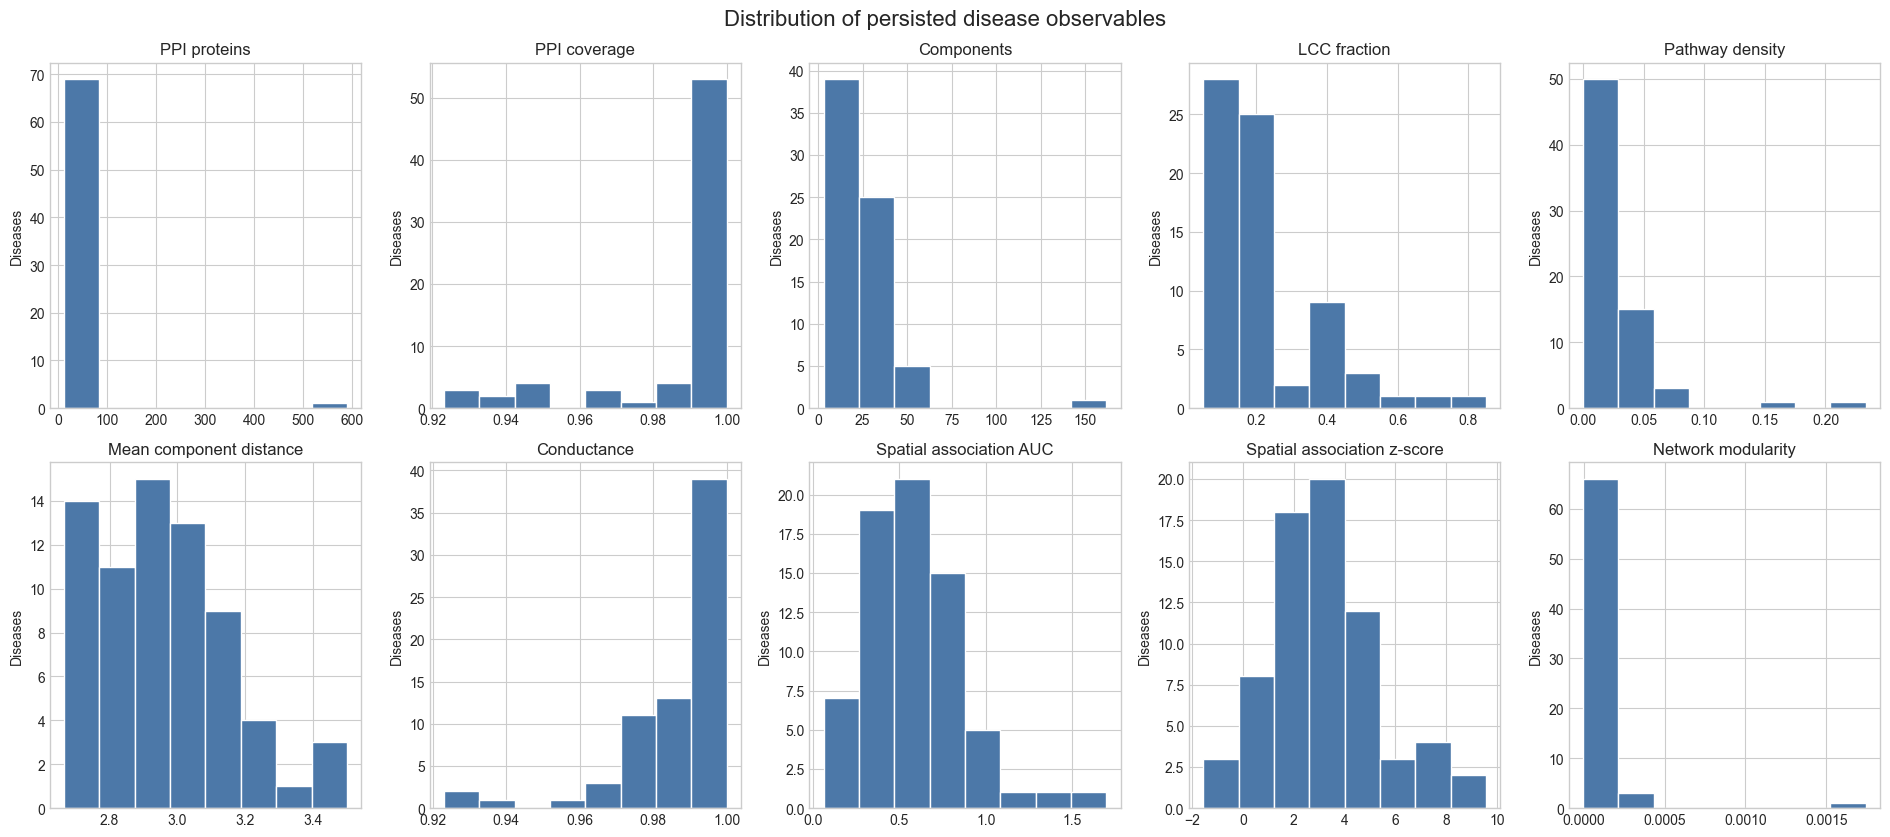

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(19, 8.5))

for axis, column in zip(axes.flat, disease_summary.columns):
    values = disease_summary[column].to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    bins = min(20, max(5, int(np.sqrt(len(values)))))
    axis.hist(values, bins=bins, color="#4C78A8", edgecolor="white")
    axis.set_title(column)
    axis.set_ylabel("Diseases")

fig.suptitle("Distribution of persisted disease observables", fontsize=16)
fig.tight_layout()
plt.show()

### Inspect one disease and its spatial-association curve

Disease: breast neoplasms
PPI proteins: 40/40 (100.0%)
Components: 19; sizes: [21, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
largest_component_fraction: 0.525
pathway_density: 0.047436
mean_component_distance: 3.0349
conductance: 0.97356
spatial_association_auc: 0.74824
spatial_association_zscore: 5.8238
spatial_association_pvalue: 0.0039841
network_modularity: 0.00017751


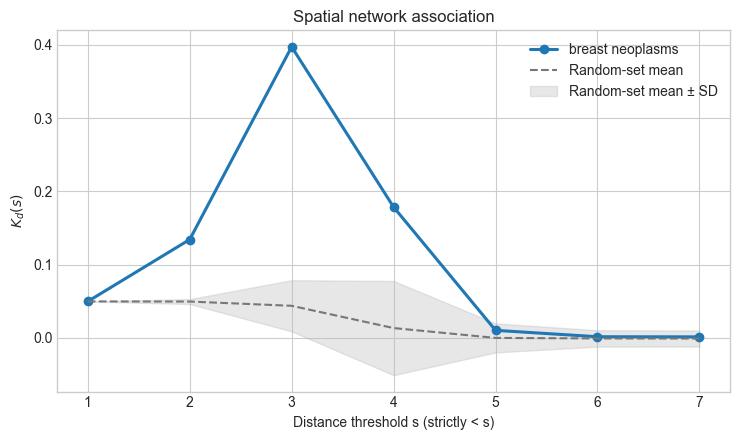

In [9]:
example_disease = "breast neoplasms"
example = diseases_prop[example_disease]

print(f"Disease: {example_disease}")
print(
    f"PPI proteins: {example['n_genes_in_ppi']}/{example['n_unique_genes']} "
    f"({example['ppi_coverage']:.1%})"
)
print(f"Components: {example['n_components']}; sizes: {example['cluster_sizes']}")
for field in [
    "largest_component_fraction",
    "pathway_density",
    "mean_component_distance",
    "conductance",
    "spatial_association_auc",
    "spatial_association_zscore",
    "spatial_association_pvalue",
    "network_modularity",
]:
    print(f"{field}: {example[field]:.5g}")

scales = example["spatial_association_scales"]
observed = example["spatial_association_k"]
null_mean = example["spatial_association_null_mean_k"]
null_std = example["spatial_association_null_std_k"]

fig, axis = plt.subplots(figsize=(7.5, 4.5))
axis.plot(scales, observed, "o-", lw=2.2, label=example_disease)
axis.plot(scales, null_mean, "--", color="#777777", label="Random-set mean")
axis.fill_between(
    scales,
    null_mean - null_std,
    null_mean + null_std,
    color="#BBBBBB",
    alpha=0.35,
    label="Random-set mean ± SD",
)
axis.set(xlabel="Distance threshold s (strictly < s)", ylabel="$K_d(s)$")
axis.set_title("Spatial network association")
axis.legend(frameon=False)
plt.tight_layout()
plt.show()

### Component-size overview and optional cluster maps

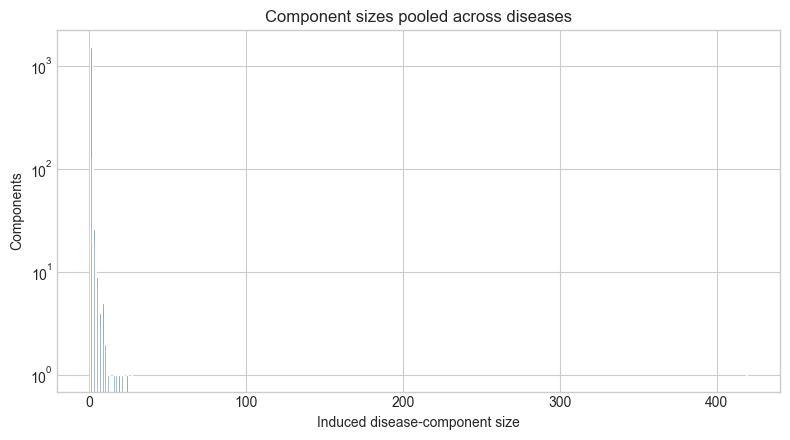

Components per disease: 24.94 ± 20.06


In [10]:
all_component_sizes = np.concatenate(
    [np.asarray(record["cluster_sizes"], dtype=int) for record in diseases_prop.values()]
)
fig, axis = plt.subplots(figsize=(8, 4.5))
bins = np.arange(0.5, all_component_sizes.max() + 1.5)
axis.hist(all_component_sizes, bins=bins, color="#4C78A8", edgecolor="white")
axis.set_yscale("log")
axis.set(
    xlabel="Induced disease-component size",
    ylabel="Components",
    title="Component sizes pooled across diseases",
)
plt.tight_layout()
plt.show()

component_counts = disease_summary["Components"]
print(
    f"Components per disease: {component_counts.mean():.2f} ± "
    f"{component_counts.std(ddof=0):.2f}"
)

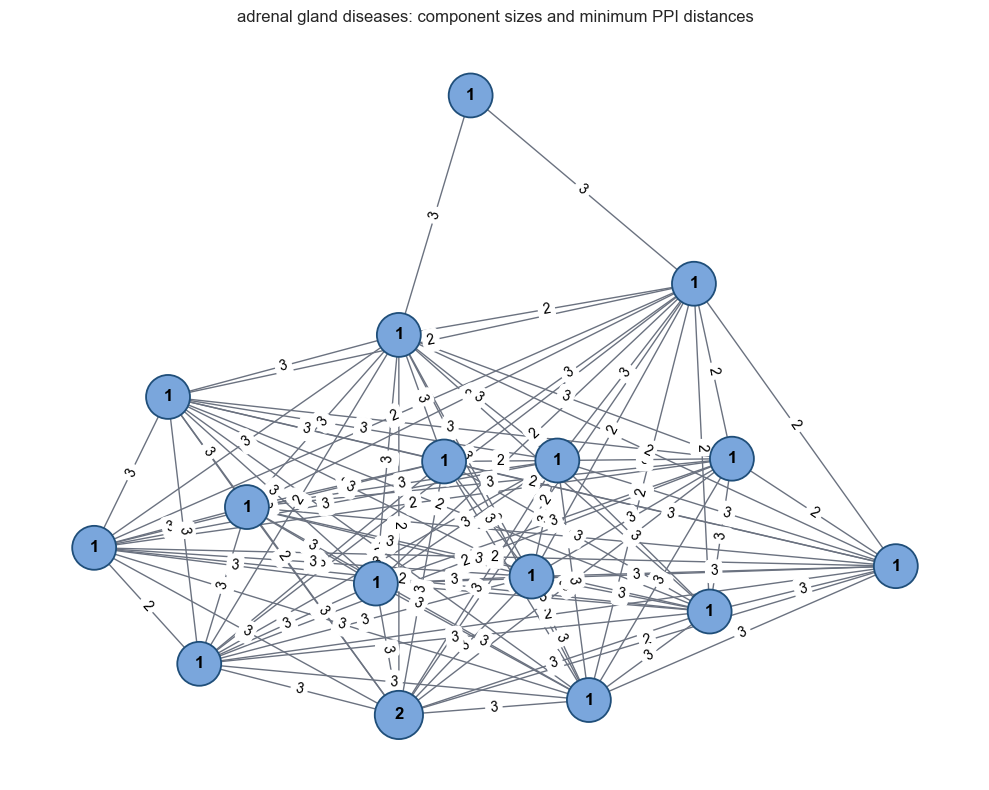

In [11]:
def plot_disease_cluster_map(disease_name, show=True):
    '''Plot induced components; edges join component pairs less than 4 PPI steps apart.'''
    record = diseases_prop[disease_name]
    sizes = np.asarray(record["cluster_sizes"])
    distances = np.asarray(record["cluster_distances"])
    component_graph = nx.Graph()
    component_graph.add_nodes_from(range(len(sizes)))

    for left in range(len(sizes)):
        for right in range(left + 1, len(sizes)):
            distance = distances[left, right]
            if np.isfinite(distance) and distance < 4:
                component_graph.add_edge(
                    left, right, distance=int(distance), weight=1 / distance
                )

    positions = nx.kamada_kawai_layout(component_graph, weight="weight")
    fig, axis = plt.subplots(figsize=(10, 8))
    nx.draw_networkx(
        component_graph,
        positions,
        labels={index: str(size) for index, size in enumerate(sizes)},
        node_size=500 + 500 * np.sqrt(sizes),
        node_color="#7AA6DC",
        edge_color="#6B7280",
        linewidths=1.3,
        edgecolors="#1F4E79",
        font_weight="bold",
        ax=axis,
    )
    nx.draw_networkx_edge_labels(
        component_graph,
        positions,
        edge_labels=nx.get_edge_attributes(component_graph, "distance"),
        ax=axis,
    )
    axis.set_title(f"{disease_name}: component sizes and minimum PPI distances")
    axis.set_axis_off()
    fig.tight_layout()
    if show:
        plt.show()
    return fig


plot_disease_cluster_map("adrenal gland diseases");

In [11]:
# Optional bulk export. This creates a multi-page PDF but does not alter diseases_prop.
EXPORT_ALL_CLUSTER_MAPS = False

if EXPORT_ALL_CLUSTER_MAPS:
    from matplotlib.backends.backend_pdf import PdfPages

    pdf_path = figures_dir / "disease_cluster_maps.pdf"
    with PdfPages(pdf_path) as pdf:
        for disease_name in sorted(diseases_prop):
            figure = plot_disease_cluster_map(disease_name, show=False)
            pdf.savefig(figure, bbox_inches="tight")
            plt.close(figure)
    print(f"Saved {len(diseases_prop)} cluster maps to {pdf_path}")

# Part II — Whole-PPI graph properties (not persisted)

The cells below examine the global PPI topology and how disease annotations sit on it. They do not modify `diseases_prop` and are not written to `diseases_prop.pkl`.

### Coordination-number distribution and global topology

Connected components: 7
Average coordination number: 40.522
Coordination-number standard deviation: 51.142
Random-graph distance estimate log(n)/log(<k>): 2.639


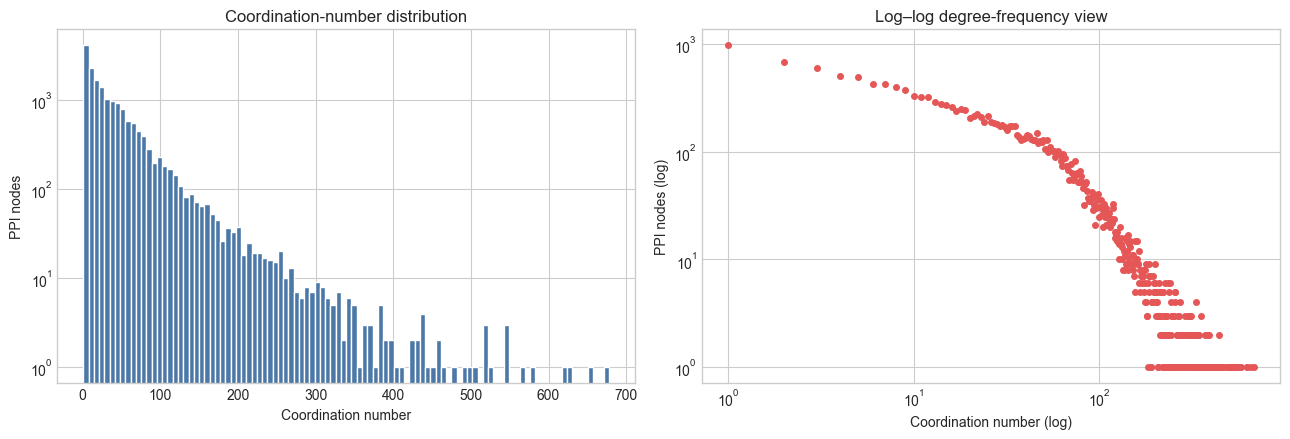

In [12]:
coordination_numbers = np.fromiter(
    (degree for _, degree in Ggen.degree()), dtype=int
)
mean_coordination = coordination_numbers.mean()
random_graph_distance_estimate = np.log(Ggen.number_of_nodes()) / np.log(
    mean_coordination
)

print(f"Connected components: {nx.number_connected_components(Ggen)}")
print(f"Average coordination number: {mean_coordination:.3f}")
print(f"Coordination-number standard deviation: {coordination_numbers.std():.3f}")
print(
    "Random-graph distance estimate log(n)/log(<k>): "
    f"{random_graph_distance_estimate:.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(coordination_numbers, bins=100, color="#4C78A8", edgecolor="white")
axes[0].set(
    xlabel="Coordination number",
    ylabel="PPI nodes",
    title="Coordination-number distribution",
)
axes[0].set_yscale("log")

positive_degrees = coordination_numbers[coordination_numbers > 0]
degree_values, degree_counts = np.unique(positive_degrees, return_counts=True)
axes[1].loglog(degree_values, degree_counts, "o", ms=4, color="#E45756")
axes[1].set(
    xlabel="Coordination number (log)",
    ylabel="PPI nodes (log)",
    title="Log–log degree-frequency view",
)
fig.tight_layout()
plt.show()

### Coordination numbers for selected diseases

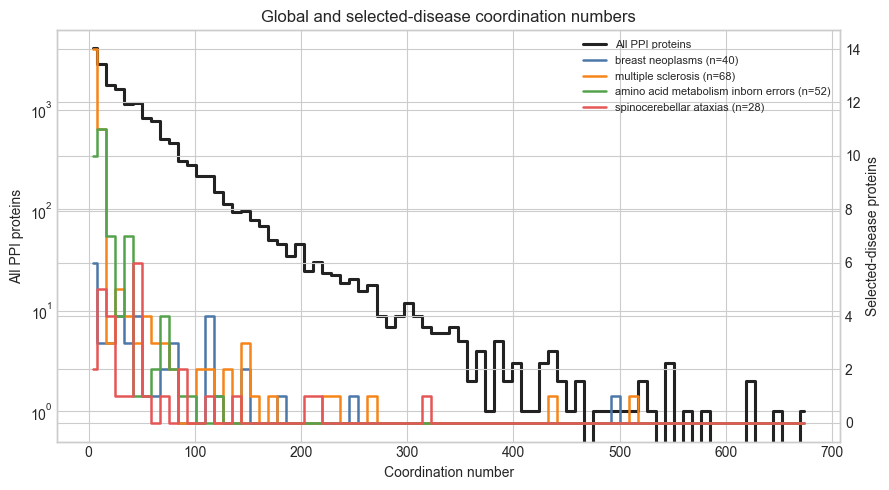

In [13]:
selected_diseases = [
    "breast neoplasms",
    "multiple sclerosis",
    "amino acid metabolism inborn errors",
    "spinocerebellar ataxias",
]

max_degree = int(coordination_numbers.max())
n_bins = min(80, max(20, max_degree // 8))
bin_edges = np.linspace(-0.5, max_degree + 0.5, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, left_axis = plt.subplots(figsize=(9, 5))
right_axis = left_axis.twinx()
baseline_counts, _ = np.histogram(coordination_numbers, bins=bin_edges)
left_axis.step(
    bin_centers,
    baseline_counts,
    where="mid",
    color="#222222",
    linewidth=2.2,
    label="All PPI proteins",
)

palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
for disease_name, color in zip(selected_diseases, palette):
    genes_in_ppi = diseases_prop[disease_name]["genes_in_ppi"]
    disease_degrees = np.array([Ggen.degree(gene) for gene in genes_in_ppi])
    counts, _ = np.histogram(disease_degrees, bins=bin_edges)
    right_axis.step(
        bin_centers,
        counts,
        where="mid",
        color=color,
        linewidth=1.8,
        label=f"{disease_name} (n={len(genes_in_ppi)})",
    )

left_axis.set_yscale("log")
left_axis.set_ylim(bottom=0.5)
left_axis.set(
    xlabel="Coordination number",
    ylabel="All PPI proteins",
    title="Global and selected-disease coordination numbers",
)
right_axis.set_ylabel("Selected-disease proteins")
handles_left, labels_left = left_axis.get_legend_handles_labels()
handles_right, labels_right = right_axis.get_legend_handles_labels()
left_axis.legend(
    handles_left + handles_right,
    labels_left + labels_right,
    frameon=False,
    fontsize=8,
)
fig.tight_layout()
plt.show()

### Gene disease-relevance frequency

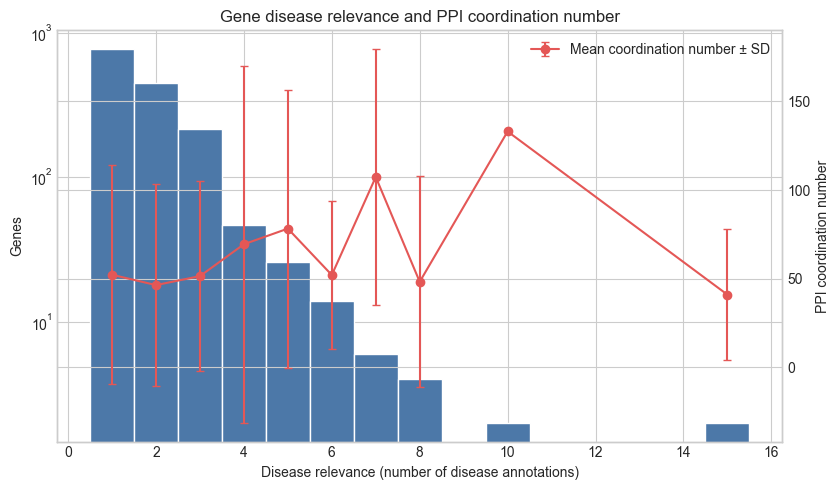

Scored 1,536 unique disease-annotated genes.


In [14]:
gene_scores = {}
for annotated_genes in diseases.values():
    for gene in set(annotated_genes):
        gene_scores[gene] = gene_scores.get(gene, 0) + 1

nx.set_node_attributes(
    Ggen,
    {gene: score for gene, score in gene_scores.items() if gene in Ggen},
    name="disease_score",
)

score_values = np.asarray(list(gene_scores.values()), dtype=int)
genes_scored_in_ppi = [gene for gene in gene_scores if gene in Ggen]
scores_in_ppi = np.array([gene_scores[gene] for gene in genes_scored_in_ppi])
degrees_in_ppi = np.array([Ggen.degree(gene) for gene in genes_scored_in_ppi])
score_levels = np.unique(scores_in_ppi)
mean_degree = np.array(
    [degrees_in_ppi[scores_in_ppi == score].mean() for score in score_levels]
)
std_degree = np.array(
    [degrees_in_ppi[scores_in_ppi == score].std() for score in score_levels]
)

fig, left_axis = plt.subplots(figsize=(8.5, 5))
right_axis = left_axis.twinx()
left_axis.hist(
    score_values,
    bins=np.arange(0.5, score_values.max() + 1.5),
    color="#4C78A8",
    edgecolor="white",
)
left_axis.set_yscale("log")
left_axis.set(
    xlabel="Disease relevance (number of disease annotations)",
    ylabel="Genes",
    title="Gene disease relevance and PPI coordination number",
)
right_axis.errorbar(
    score_levels,
    mean_degree,
    yerr=std_degree,
    fmt="o-",
    color="#E45756",
    capsize=3,
    label="Mean coordination number ± SD",
)
right_axis.set_ylabel("PPI coordination number")
right_axis.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Scored {len(gene_scores):,} unique disease-annotated genes.")

### PPI-edge disease relevance

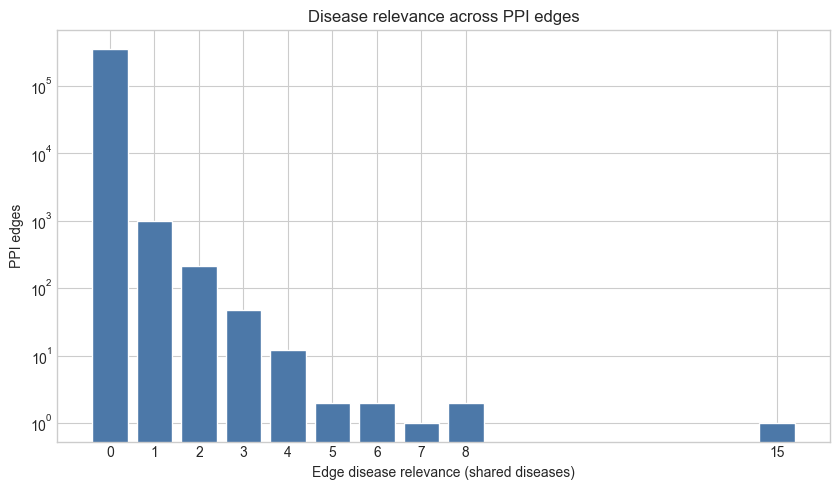

1,278 of 354,647 PPI edges connect genes from at least one common disease.


,gene_a,symbol_a,gene_b,symbol_b,disease_relevance_score,shared_diseases
0,3118,HLA-DQA2,3119,HLA-DQB1,15,"[arthritis rheumatoid, asthma, bile duct disea..."
1,3117,HLA-DQA1,3119,HLA-DQB1,8,"[arthritis rheumatoid, asthma, glomerulonephri..."
2,3118,HLA-DQA2,3117,HLA-DQA1,8,"[arthritis rheumatoid, asthma, glomerulonephri..."
3,3122,HLA-DRA,3119,HLA-DQB1,7,"[asthma, lung diseases obstructive, lupus eryt..."
4,3122,HLA-DRA,3117,HLA-DQA1,6,"[asthma, lung diseases obstructive, lupus eryt..."
5,3123,HLA-DRB1,3119,HLA-DQB1,6,"[arthritis rheumatoid, glomerulonephritis, lup..."
6,3107,HLA-C,3106,HLA-B,5,"[behcet syndrome, multiple sclerosis, psoriasi..."
7,149233,IL23R,3593,IL12B,5,"[colitis ulcerative, crohn disease, mycobacter..."
8,8546,AP3B1,84062,DTNBP1,4,"[amino acid metabolism inborn errors, blood co..."
9,84062,DTNBP1,388552,BLOC1S3,4,"[amino acid metabolism inborn errors, blood co..."


In [15]:
gene_disease_memberships = {}
for disease_name, annotated_genes in diseases.items():
    for gene in set(annotated_genes):
        gene_disease_memberships.setdefault(gene, set()).add(disease_name)

edge_score_counts = np.zeros(len(diseases) + 1, dtype=np.int64)
ranked_disease_edges = []
for gene_a, gene_b in Ggen.edges():
    shared_diseases = (
        gene_disease_memberships.get(gene_a, set())
        & gene_disease_memberships.get(gene_b, set())
    )
    score = len(shared_diseases)
    edge_score_counts[score] += 1
    if score:
        ranked_disease_edges.append(
            {
                "gene_a": gene_a,
                "symbol_a": Ggen.nodes[gene_a].get("symbol", str(gene_a)),
                "gene_b": gene_b,
                "symbol_b": Ggen.nodes[gene_b].get("symbol", str(gene_b)),
                "disease_relevance_score": score,
                "shared_diseases": sorted(shared_diseases),
            }
        )

ranked_disease_edges.sort(
    key=lambda edge: (
        -edge["disease_relevance_score"], edge["symbol_a"], edge["symbol_b"]
    )
)
observed_scores = np.flatnonzero(edge_score_counts)

fig, axis = plt.subplots(figsize=(8.5, 5))
axis.bar(
    observed_scores,
    edge_score_counts[observed_scores],
    width=0.8,
    color="#4C78A8",
    edgecolor="white",
)
axis.set_yscale("log")
axis.set_xticks(observed_scores)
axis.set(
    xlabel="Edge disease relevance (shared diseases)",
    ylabel="PPI edges",
    title="Disease relevance across PPI edges",
)
plt.tight_layout()
plt.show()

print(
    f"{len(ranked_disease_edges):,} of {Ggen.number_of_edges():,} PPI edges "
    "connect genes from at least one common disease."
)
display(pd.DataFrame(ranked_disease_edges[:20]))